Code generated by Gemini.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

file_path = '/content/drive/path/ratebeer.json'
df = pd.read_json(file_path, lines=True)
print(df.head())

                            beer/name beer/beerId  beer/brewerId beer/ABV  \
0            John Harvards Simcoe IPA       63836         8481.0      5.4   
1            John Harvards Simcoe IPA       63836         8481.0      5.4   
2       John Harvards Cristal Pilsner       71716         8481.0        5   
3  John Harvards Fancy Lawnmower Beer       64125         8481.0      5.4   
4  John Harvards Fancy Lawnmower Beer       64125         8481.0      5.4   

                     beer/style review/appearance review/aroma review/palate  \
0  India Pale Ale &#40;IPA&#41;               4/5         6/10           3/5   
1  India Pale Ale &#40;IPA&#41;               4/5         6/10           4/5   
2             Bohemian Pilsener               4/5         5/10           3/5   
3                         Klsch               2/5         4/10           2/5   
4                         Klsch               2/5         4/10           2/5   

  review/taste review/overall   review/time review/profi

In [ ]:
def normalize_score(value, denominator):
    try:
        if isinstance(value, str) and '/' in value:
            score = float(value.split('/')[0])
            return (score / denominator) * 5
        return float(value)
    except:
        return None

# Normalize individual components
# appearance: x/5 -> already out of 5, just strip string
# aroma: x/10 -> (x/10)*5
# palate: x/5 -> already out of 5
# taste: x/10 -> (x/10)*5
# overall: x/20 -> (x/20)*5

df['review/appearance_norm'] = df['review/appearance'].apply(lambda x: normalize_score(x, 5))
df['review/aroma_norm'] = df['review/aroma'].apply(lambda x: normalize_score(x, 10))
df['review/palate_norm'] = df['review/palate'].apply(lambda x: normalize_score(x, 5))
df['review/taste_norm'] = df['review/taste'].apply(lambda x: normalize_score(x, 10))
df['review/overall_norm'] = df['review/overall'].apply(lambda x: normalize_score(x, 20))

display(df[['review/appearance', 'review/appearance_norm', 'review/aroma', 'review/aroma_norm', 'review/overall', 'review/overall_norm']].head())

,review/appearance,review/appearance_norm,review/aroma,review/aroma_norm,review/overall,review/overall_norm
0,4/5,4.0,6/10,3.0,13/20,3.25
1,4/5,4.0,6/10,3.0,13/20,3.25
2,4/5,4.0,5/10,2.5,14/20,3.50
3,2/5,2.0,4/10,2.0,8/20,2.00
4,2/5,2.0,4/10,2.0,8/20,2.00


In [ ]:
# Replace original columns with normalized values
score_mapping = {
    'review/appearance_norm': 'review/appearance',
    'review/aroma_norm': 'review/aroma',
    'review/palate_norm': 'review/palate',
    'review/taste_norm': 'review/taste',
    'review/overall_norm': 'review/overall'
}

for norm_col, original_col in score_mapping.items():
    df[original_col] = df[norm_col]

# Drop the temporary _norm columns
df = df.drop(columns=list(score_mapping.keys()))

print("Updated dataframe with normalized scores (0-5 scale):")
display(df[['beer/name', 'review/appearance', 'review/aroma', 'review/palate', 'review/taste', 'review/overall']].head())

Updated dataframe with normalized scores (0-5 scale):


,beer/name,review/appearance,review/aroma,review/palate,review/taste,review/overall
0,John Harvards Simcoe IPA,4.0,3.0,3.0,3.0,3.25
1,John Harvards Simcoe IPA,4.0,3.0,4.0,3.5,3.25
2,John Harvards Cristal Pilsner,4.0,2.5,3.0,3.0,3.50
3,John Harvards Fancy Lawnmower Beer,2.0,2.0,2.0,2.0,2.00
4,John Harvards Fancy Lawnmower Beer,2.0,2.0,2.0,2.0,2.00


In [ ]:
# General information about columns and types
print("--- Dataframe Info ---")
display(df.info())

# Summary statistics for numerical columns
print("\n--- Numerical Summary ---")
display(df.describe())

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924164 entries, 0 to 2924163
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   beer/name           object 
 1   beer/beerId         object 
 2   beer/brewerId       float64
 3   beer/ABV            object 
 4   beer/style          object 
 5   review/appearance   float64
 6   review/aroma        float64
 7   review/palate       float64
 8   review/taste        float64
 9   review/overall      float64
 10  review/time         float64
 11  review/profileName  object 
 12  review/text         object 
dtypes: float64(7), object(6)
memory usage: 290.0+ MB


None


--- Numerical Summary ---


,beer/brewerId,review/appearance,review/aroma,review/palate,review/taste,review/overall,review/time
count,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06,2.924163e+06
mean,2.098489e+03,3.432027e+00,3.176804e+00,3.257236e+00,3.225964e+00,3.299924e+00,1.204993e+09
std,3.055098e+03,8.125569e-01,8.195824e-01,8.297312e-01,8.114442e-01,8.381448e-01,8.248921e+07
min,1.000000e+00,1.000000e+00,5.000000e-01,1.000000e+00,5.000000e-01,2.500000e-01,9.554976e+08
25%,1.670000e+02,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,1.148429e+09
50%,6.780000e+02,3.000000e+00,3.500000e+00,3.000000e+00,3.500000e+00,3.500000e+00,1.215475e+09
75%,2.676000e+03,4.000000e+00,3.500000e+00,4.000000e+00,4.000000e+00,3.750000e+00,1.273363e+09
max,1.394600e+04,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,1.326413e+09


In [ ]:
# Count unique values for specific columns
unique_counts = {
    'Unique Beers (Names)': df['beer/name'].nunique(),
    'Unique Beer IDs': df['beer/beerId'].nunique(),
    'Unique Brewer IDs': df['beer/brewerId'].nunique(),
    'Unique Beer Styles': df['beer/style'].nunique(),
    'Unique Reviewers': df['review/profileName'].nunique()
}

for key, value in unique_counts.items():
    print(f"{key}: {value:,}")

num_interactions = len(df)
num_users = df['review/profileName'].nunique()
num_beers = df['beer/name'].nunique()

# Density = Interactions / (Users * Items)
density = (num_interactions / (num_users * num_beers)) * 100

print(f"Total Interactions: {num_interactions:,}")
print(f"Sparsity/Density: {density:.4f}%")

Unique Beers (Names): 110,299
Unique Beer IDs: 110,369
Unique Brewer IDs: 7,547
Unique Beer Styles: 89
Unique Reviewers: 29,265
Total Interactions: 2,924,164
Sparsity/Density: 0.0906%


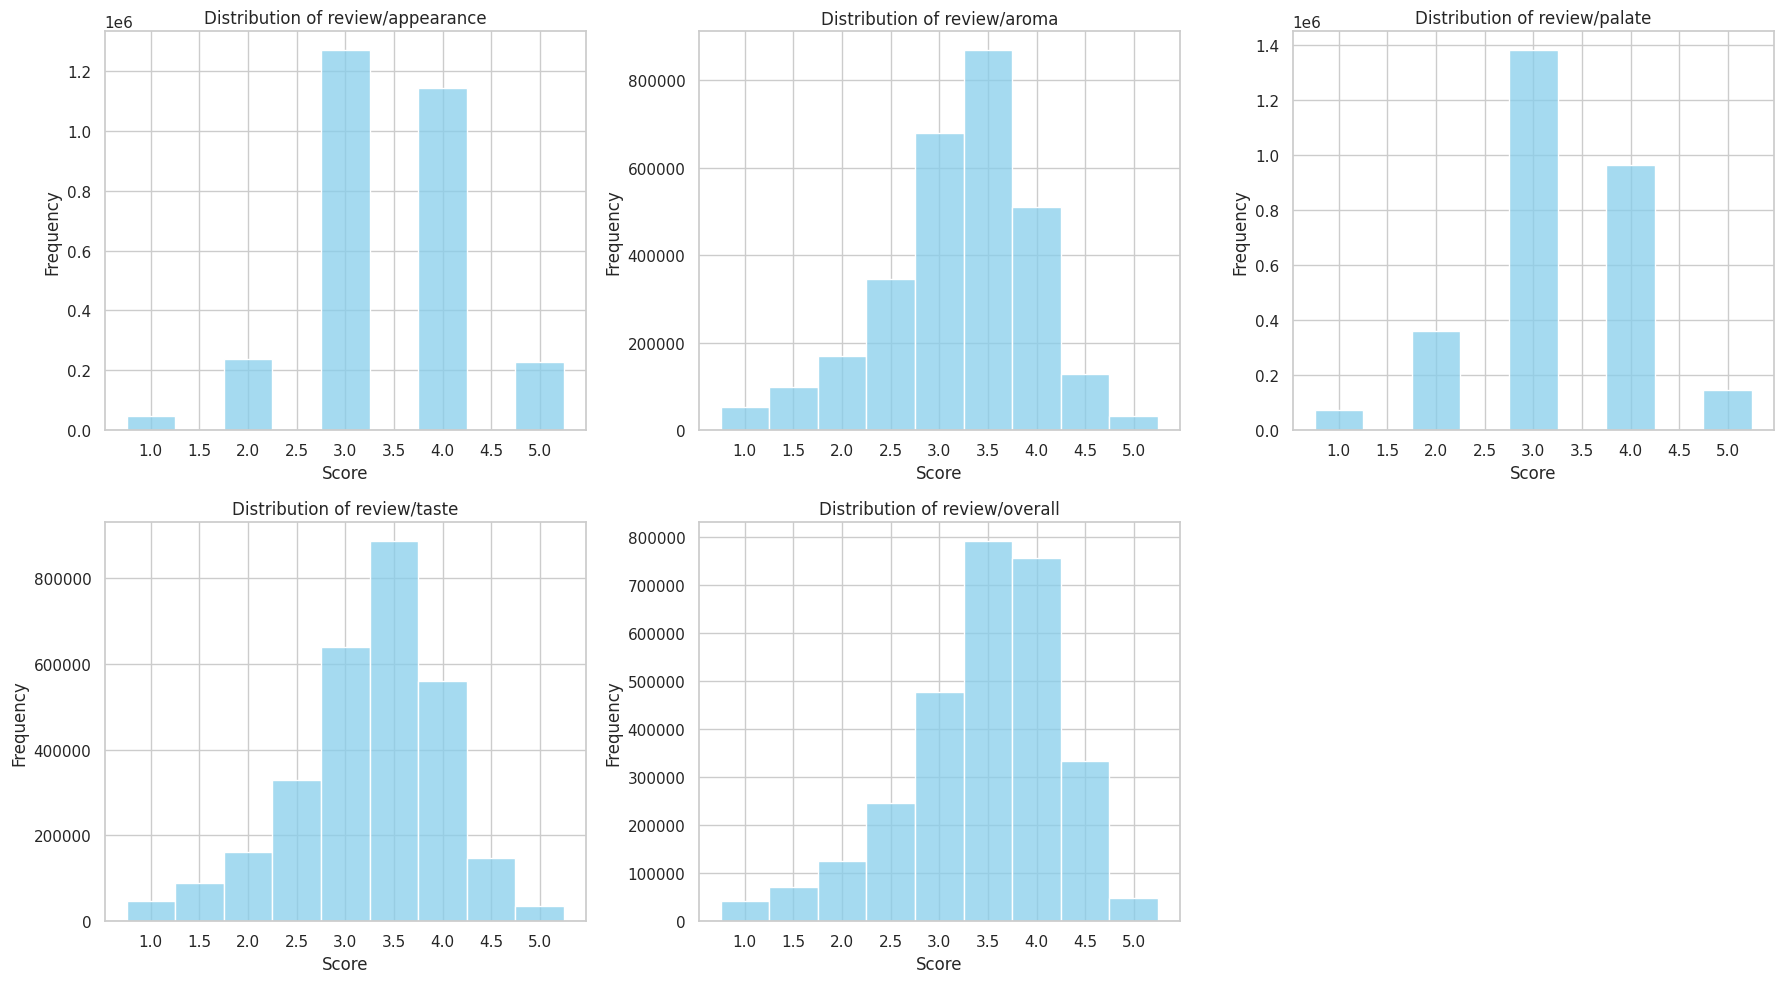

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for the plots
sns.set(style="whitegrid")

# List of rating columns to visualize
rating_cols = ['review/appearance', 'review/aroma', 'review/palate', 'review/taste', 'review/overall']

# Create a figure with subplots for ratings
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Ratings are typically in increments of 0.5 from 1 to 5
bins = np.arange(1, 6, 0.5) - 0.25

for i, col in enumerate(rating_cols):
    sns.histplot(df[col], bins=np.arange(0.75, 5.75, 0.5), kde=False, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xticks(np.arange(1, 5.5, 0.5))

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

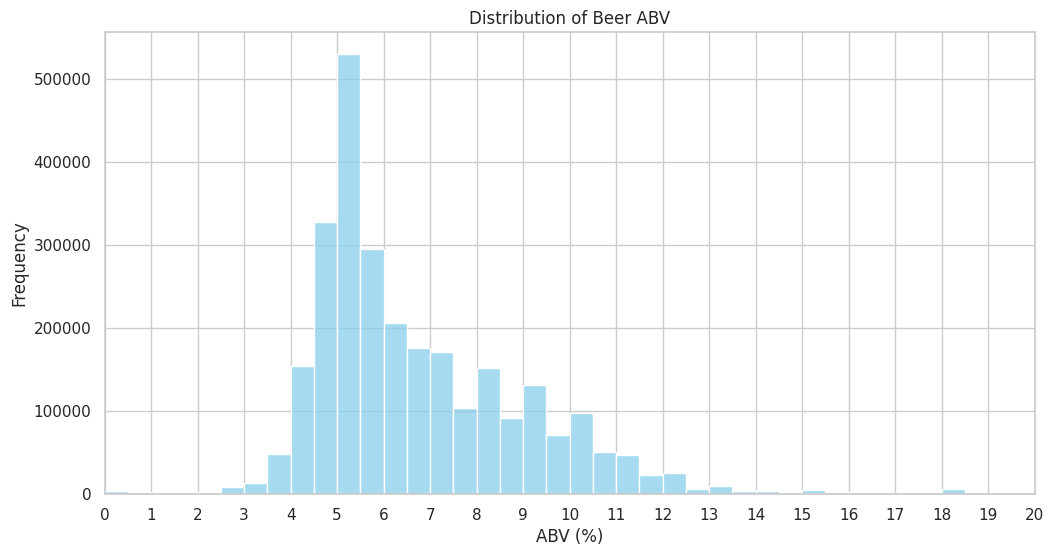

In [ ]:
# Visualize ABV distribution
plt.figure(figsize=(12, 6))

# Convert to numeric, coercing errors to NaN
abv_numeric = pd.to_numeric(df['beer/ABV'], errors='coerce').dropna()

# Defining bins to align with whole numbers/increments
bins = np.arange(0, 21, 0.5)

sns.histplot(abv_numeric, bins=bins, kde=False, color='skyblue')
plt.title('Distribution of Beer ABV')
plt.xlabel('ABV (%)')
plt.ylabel('Frequency')

# Setting x-ticks to show clear increments
plt.xticks(np.arange(0, 21, 1))
plt.xlim(0, 20)
plt.show()

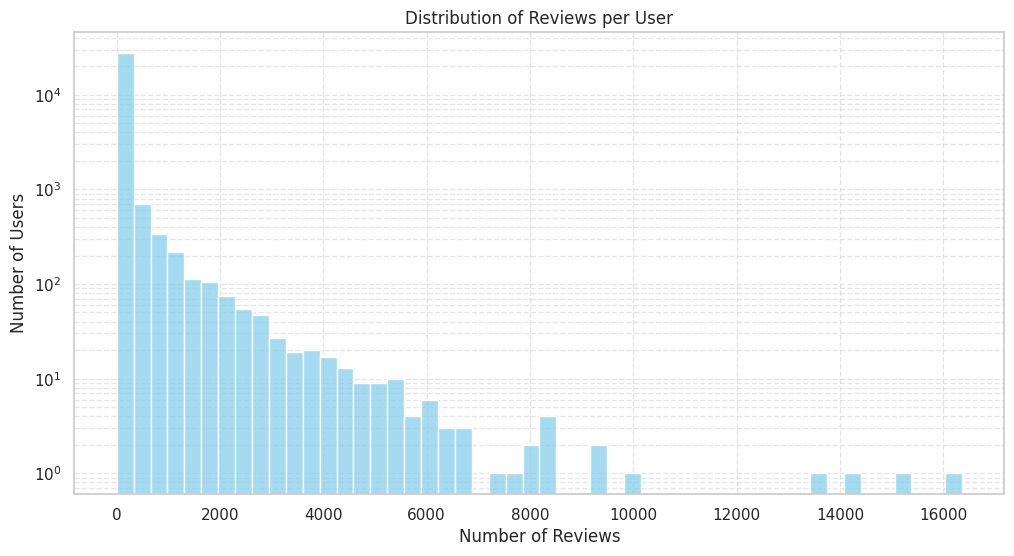

Average reviews per user: 99.92
Median reviews per user: 3.00
Mode of reviews per user: 1.00
Max reviews per user: 16,364


In [ ]:
# Calculate interactions per user
user_counts = df['review/profileName'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(user_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribution of Reviews per User')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users')

# Using log scale for x-axis as interaction counts often follow a long tail
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Average reviews per user: {user_counts.mean():.2f}")
print(f"Median reviews per user: {user_counts.median():.2f}")
print(f"Mode of reviews per user: {user_counts.mode()[0]:.2f}")
print(f"Max reviews per user: {user_counts.max():,}")

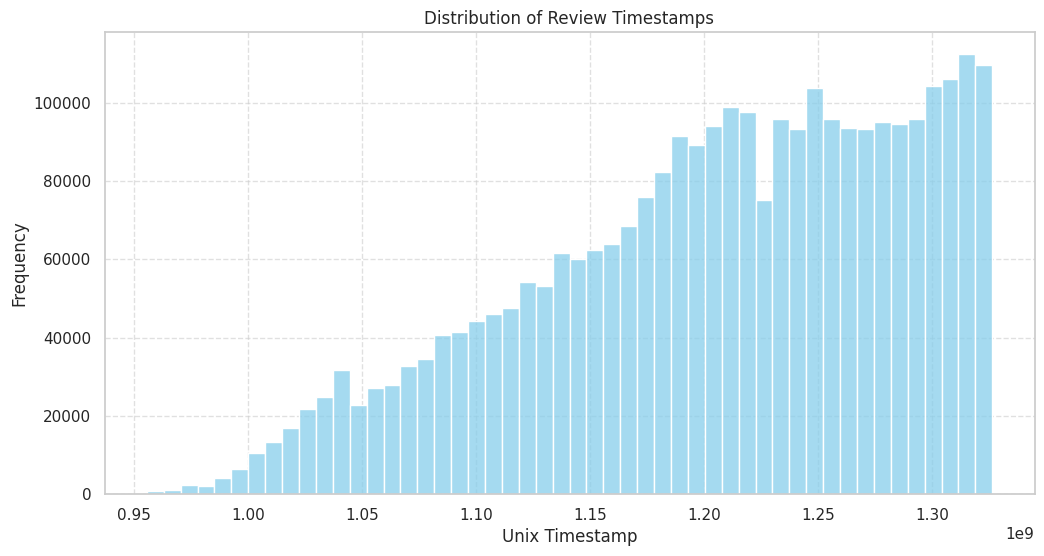

Dataset spans from 2000-04-12 00:00:00 to 2012-01-13 00:00:00


In [ ]:
# Visualize the distribution of review timestamps
plt.figure(figsize=(12, 6))

sns.histplot(df['review/time'], bins=50, kde=False, color='skyblue')
plt.title('Distribution of Review Timestamps')
plt.xlabel('Unix Timestamp')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Optional: Convert min and max to human-readable dates for context
import datetime
min_time = datetime.datetime.fromtimestamp(df['review/time'].min())
max_time = datetime.datetime.fromtimestamp(df['review/time'].max())
print(f"Dataset spans from {min_time} to {max_time}")

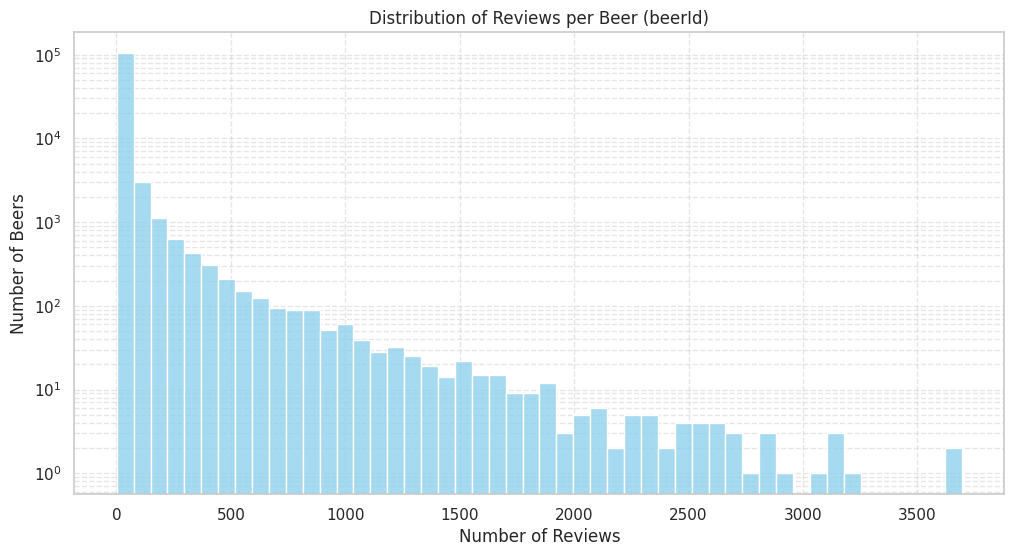

Average reviews per beer: 26.49
Median reviews per beer: 4.00
Max reviews for a single beer: 3,696


In [ ]:
# Calculate interactions per beer
beer_counts = df['beer/beerId'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(beer_counts, bins=50, kde=False, color='skyblue')
plt.title('Distribution of Reviews per Beer (beerId)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Beers')

# Using log scale for y-axis as beer popularity usually follows a power law
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Average reviews per beer: {beer_counts.mean():.2f}")
print(f"Median reviews per beer: {beer_counts.median():.2f}")
print(f"Max reviews for a single beer: {beer_counts.max():,}")